In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm

from match3.game.level import Level, Objective, ObjectiveType
from match3.players.greedy_player import GreedyPlayer
from match3.players.random_player import RandomPlayer
from match3.simulation.simulator import simulate_games

In [2]:
N_GAMES = 500
SEED = 42

In [3]:
random_player = RandomPlayer(
    rng=np.random.default_rng(SEED)
)

greedy_player = GreedyPlayer(
    rng=np.random.default_rng(SEED)
)

## Baseline Testing

In [4]:
level = Level(
    name="Baseline",
    moves=20,
    objective=Objective(
        type=ObjectiveType.COLLECT,
        target=15,
        candy_type=0,
    ),
)

In [5]:
random_results = simulate_games(
    level=level,
    player=random_player,
    n_games=N_GAMES,
    rng=np.random.default_rng(SEED),
)

greedy_results = simulate_games(
    level=level,
    player=greedy_player,
    n_games=N_GAMES,
    rng=np.random.default_rng(SEED),
)

In [6]:
len(random_results), len(greedy_results)

(500, 500)

In [7]:
random_results[0]

SimulationResult(won=False, moves_used=20, moves_remaining=0, objective_progress=np.int64(12), cascade_count=1)

In [8]:
greedy_results[0]

SimulationResult(won=True, moves_used=13, moves_remaining=7, objective_progress=np.int64(15), cascade_count=1)

In [9]:
def results_to_dataframe(results, player_name):
    return pd.DataFrame(
        [
            {
                "player": player_name,
                "won": result.won,
                "moves_used": result.moves_used,
                "moves_remaining": result.moves_remaining,
                "objective_progress": result.objective_progress,
                "cascade_count": result.cascade_count,
            }
            for result in results
        ]
    )

In [10]:
random_df = results_to_dataframe(
    random_results,
    "Random",
)

greedy_df = results_to_dataframe(
    greedy_results,
    "Greedy",
)

In [11]:
results_df = pd.concat(
    [random_df, greedy_df],
    ignore_index=True,
)

results_df.head()

,player,won,moves_used,moves_remaining,objective_progress,cascade_count
0,Random,False,20,0,12,1
1,Random,True,18,2,15,2
2,Random,True,12,8,16,2
3,Random,True,19,1,16,1
4,Random,True,14,6,15,3


In [12]:
summary = (
    results_df
    .groupby("player")
    .agg(
        win_rate=("won", "mean"),
        mean_moves_used=("moves_used", "mean"),
        mean_moves_remaining=("moves_remaining", "mean"),
        mean_objective_progress=("objective_progress", "mean"),
        mean_cascades=("cascade_count", "mean"),
    )
)

summary

,win_rate,mean_moves_used,mean_moves_remaining,mean_objective_progress,mean_cascades
player,,,,,
Greedy,0.904,13.144,6.856,15.184,1.668
Random,0.640,16.736,3.264,13.844,1.748


The first thing we see is that the Greedy player has a 90% win rate, vs the Random player with only 64%.

The greedy player also uses fewer moves to complete the objective.

#### Move Count

In [13]:
results_df.groupby(["player", "won"])["moves_used"].agg(
    ["count", "mean", "std", "min", "max"]
)

count       mean       std  min  max
player won                                        
Greedy False     48  19.437500  1.955965   11   20
       True     452  12.475664  3.938759    3   20
Random False    180  19.894444  1.032961    8   20
       True     320  14.959375  3.457068    5   20

What's particularly interesting is that the Greedy and Random agent both use a similar number of moves when they lose, which makes sense because most of the time, it would be because they ran out of moves, not a lack of possible moves to make.

#### Objective Progress

In [14]:
objective_summary = (
    results_df
    .groupby(["player", "won"])["objective_progress"]
    .agg(["count", "mean", "std", "min", "max"])
)

objective_summary

count       mean       std  min  max
player won                                        
Greedy False     48  11.645833  1.328727    9   14
       True     452  15.559735  0.968904   15   23
Random False    180  10.622222  2.340213    3   14
       True     320  15.656250  1.144960   15   23

The success doesn't really matter here because the objective progress is capped at the target.

However, when looking at failures, the greedy agent still scores slightly higher, 11.6 vs 10.6 avg score.

The standard deviation of Greedy progress is smaller than the Random progress too; the greedy player is more consistent.

#### How far away are they when they lose?

In [15]:
results_df["objective_shortfall"] = (
    level.objective.target - results_df["objective_progress"]
).clip(lower=0)

(
    results_df[~results_df["won"]]
    .groupby("player")["objective_shortfall"]
    .agg(["mean", "std", "min", "max"])
)

,mean,std,min,max
player,,,,
Greedy,3.354167,1.328727,1,6
Random,4.377778,2.340213,1,12


#### Plot Shortfall Distribution

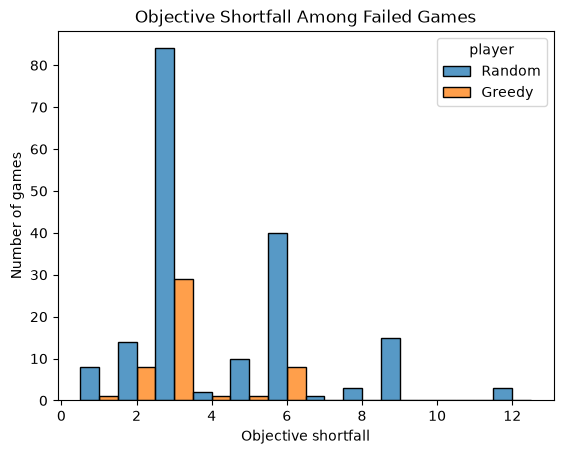

In [16]:
failure_df = results_df[~results_df["won"]]

sns.histplot(
    data=failure_df,
    x="objective_shortfall",
    hue="player",
    discrete=True,
    multiple="dodge",
)

plt.xlabel("Objective shortfall")
plt.ylabel("Number of games")
plt.title("Objective Shortfall Among Failed Games")
plt.show()

Greedy failures are concentrated around shortfalls of 2–3 and 5–6.

Random has a much wider distribution, including failures with shortfalls of 8, 9 and 12.

## Comparison vs increasing difficulty

In [17]:
TARGETS = range(10, 31)
N_GAMES = 500
BASE_SEED = 42

In [18]:
sweep_results = []

for target in TARGETS:
    level = Level(
        name=f"Target {target}",
        moves=20,
        objective=Objective(
            type=ObjectiveType.COLLECT,
            target=target,
            candy_type=0,
        ),
    )

    # Give each target condition its own reproducible RNG streams.
    condition_seed = BASE_SEED + target

    random_player = RandomPlayer(
        rng=np.random.default_rng(condition_seed)
    )

    greedy_player = GreedyPlayer(
        rng=np.random.default_rng(condition_seed)
    )

    random_results = simulate_games(
        level=level,
        player=random_player,
        n_games=N_GAMES,
        rng=np.random.default_rng(condition_seed),
    )

    greedy_results = simulate_games(
        level=level,
        player=greedy_player,
        n_games=N_GAMES,
        rng=np.random.default_rng(condition_seed),
    )

    for result in random_results:
        sweep_results.append(
            {
                "target": target,
                "player": "Random",
                "won": result.won,
                "moves_used": result.moves_used,
                "moves_remaining": result.moves_remaining,
                "objective_progress": result.objective_progress,
                "cascade_count": result.cascade_count,
            }
        )

    for result in greedy_results:
        sweep_results.append(
            {
                "target": target,
                "player": "Greedy",
                "won": result.won,
                "moves_used": result.moves_used,
                "moves_remaining": result.moves_remaining,
                "objective_progress": result.objective_progress,
                "cascade_count": result.cascade_count,
            }
        )

In [19]:
sweep_df = pd.DataFrame(sweep_results)
print(len(sweep_df), "rows in sweep_df")
sweep_df.groupby(["target", "player"]).size()

21000 rows in sweep_df


target  player
10      Greedy    500
        Random    500
11      Greedy    500
        Random    500
12      Greedy    500
        Random    500
13      Greedy    500
        Random    500
14      Greedy    500
        Random    500
15      Greedy    500
        Random    500
16      Greedy    500
        Random    500
17      Greedy    500
        Random    500
18      Greedy    500
        Random    500
19      Greedy    500
        Random    500
20      Greedy    500
        Random    500
21      Greedy    500
        Random    500
22      Greedy    500
        Random    500
23      Greedy    500
        Random    500
24      Greedy    500
        Random    500
25      Greedy    500
        Random    500
26      Greedy    500
        Random    500
27      Greedy    500
        Random    500
28      Greedy    500
        Random    500
29      Greedy    500
        Random    500
30      Greedy    500
        Random    500
dtype: int64

In [20]:
win_rates = (
    sweep_df
    .groupby(["target", "player"])
    .agg(
        win_rate=("won", "mean"),
    )
    .reset_index()
)

win_rates

,target,player,win_rate
0,10,Greedy,0.978
1,10,Random,0.890
2,11,Greedy,0.964
3,11,Random,0.864
4,12,Greedy,0.968
5,12,Random,0.858
6,13,Greedy,0.930
7,13,Random,0.688
8,14,Greedy,0.878
9,14,Random,0.656


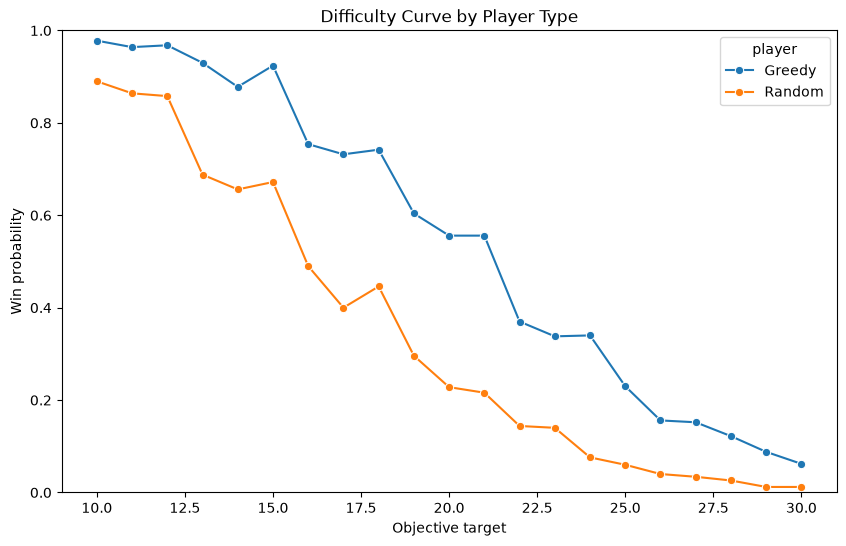

In [21]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=win_rates,
    x="target",
    y="win_rate",
    hue="player",
    marker="o",
)

plt.xlabel("Objective target")
plt.ylabel("Win probability")
plt.title("Difficulty Curve by Player Type")
plt.ylim(0, 1)
plt.show()

Note that the greedy player maintains a higher rate of success for longer than the random player.

It also maintains an advantage over the random player the whole curve.

Also this shows a flaw in how we are scoring; there are relative spikes in success for scores of multiples of 3. That is due to our objective design. Still though, the trend shows.